In [1]:
from urllib.request import urlretrieve

In [2]:
medical_charges_ur1 = 'https://raw.githubusercontent.com/JovianML/opendatasets/master/data/medical-charges.csv'

In [3]:
urlretrieve(medical_charges_ur1 , 'medical.csv')

('medical.csv', <http.client.HTTPMessage at 0x2937e47a350>)

In [4]:
import pandas as pd

In [5]:
medical_df = pd.read_csv('medical.csv')
medical_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [6]:
medical_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [7]:
medical_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
import plotly.io as pio
pio.renderers.default = "notebook"

In [9]:
pio.renderers.default = "notebook_connected"

In [10]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [11]:
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

# age

In [12]:
medical_df.age.describe()

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

In [13]:
fig = px.histogram(
                    medical_df,
                    x = 'age',
                    marginal='box',
                    nbins= 47,
                    title= 'Distribution of AGE'
)
fig.update_layout(bargap = 0.1)
fig.show()

# Body mass Index (BMI)

In [14]:
fig = px.histogram(medical_df,
                   x = 'bmi',
                   marginal='box',
                   color_discrete_sequence=['red'],
                   title='Distribution of BMI')
fig.update_layout(bargap = 0.1)
fig.show()

# Charges

In [15]:
fig = px.histogram(medical_df,
                   x = 'charges',
                   color='smoker',
                   color_discrete_sequence=['grey' , 'green'],
                   title='Annual Medical Charges')

fig.update_layout(bargap = 0.1)
fig.show()

# sex

In [16]:
fig = px.histogram(medical_df,
                   x = 'smoker',
                   color='sex',
                   color_discrete_sequence= ['pink' , 'grey'],
                   title='Medical Charges based on sex')
fig.update_layout(bargap = 0.1)
fig.show()

# region

In [17]:
fig = px.histogram(medical_df,
             x = 'smoker',
             color='region',
             color_discrete_sequence=['grey' , 'Green' , 'red' , 'blue']
             ,title='Distribution of Charges by region')
fig.update_layout(bargap = 0.1)
fig.show()

# relationship b/w age and charges

In [18]:
fig = px.scatter(medical_df,
                 x = 'age',
                 y = 'charges',
                 color='smoker',
                 opacity= 0.8,
                 hover_data= ['sex'],
                 title='Age V/S Charges')
fig.update_traces(marker_size = 5)
fig.show()

# BMI V/S Charges

In [19]:
fig =px.scatter(medical_df,
                x = 'bmi',
                y = 'charges',
                color='smoker',
                hover_data=['sex'],
                title='BMI V/S Charges')
fig.update_traces(marker_size = 5)
fig.show()

# children vs charges

In [20]:
fig =px.violin(medical_df,
                x = 'children',
                y = 'charges',
                title='Children V/S Charges')
fig.update_traces(marker_size = 5)
fig.show()

# sex vs charges

In [21]:
fig =px.violin(medical_df,
                x = 'sex',
                y = 'charges',
                color='smoker',
                hover_data=['sex'],
                title='Sex V/S Charges')
fig.update_traces(marker_size = 5)
fig.show()

# Region Vs Charces

In [22]:
fig =px.violin(medical_df,
                x = 'region',
                y = 'charges',
                color='smoker',
                title='region V/S Charges')
fig.update_traces(marker_size = 5)
fig.show()

# Relationship b/w smokers and non smokers

In [23]:
fig =px.violin(medical_df,
                x = 'smoker',
                y = 'charges',
                color='smoker',
               color_discrete_sequence= ['red' , 'green'],
                title='smoker V/S Charges')
fig.update_traces(marker_size = 5)
fig.show()

# Correlation

In [24]:
print(medical_df.charges.corr(medical_df.age))

0.2990081933306478


In [25]:
print(medical_df.charges.corr(medical_df.bmi))

0.19834096883362887


In [26]:
print(medical_df.charges.corr(medical_df.children))


0.06799822684790487


In [27]:
smoker_value = {'yes' : 1 , 'no':0}
smoker_numeric = medical_df.smoker.map(smoker_value)
print(medical_df.charges.corr(smoker_numeric))

0.7872514304984778


In [28]:
medical_df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


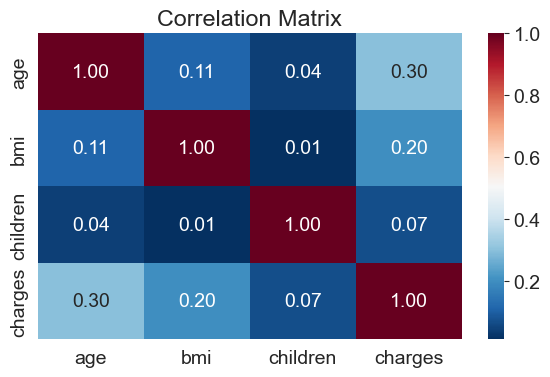

In [29]:
corr_matrix = medical_df.corr(numeric_only=True)

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='RdBu_r',
            fmt='.2f')

plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

# Linear Regression
building model for non-smoker people

In [30]:
non_smoker_df = medical_df[medical_df.smoker == 'no']
non_smoker_df

,age,sex,bmi,children,smoker,region,charges
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
...,...,...,...,...,...,...,...
1332,52,female,44.700,3,no,southwest,11411.68500
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350


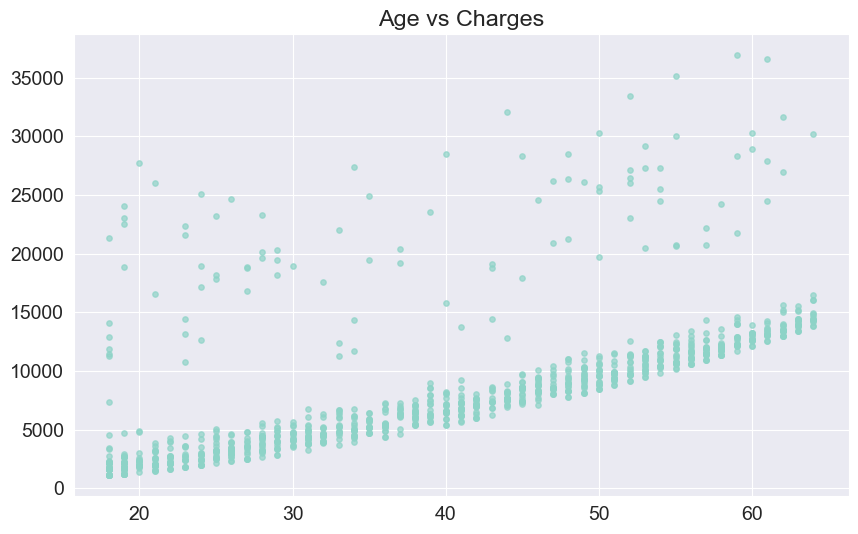

In [31]:
plt.title('Age vs Charges')
plt.scatter(data=non_smoker_df , x='age' , y = 'charges' , alpha=0.7 , s=15)
plt.show()

In [32]:
def estimate_charges(age , w , b):
    return w * age + b

In [33]:
w = 50
b = 100
ages = non_smoker_df.age
estimate_values = estimate_charges(ages , w , b)

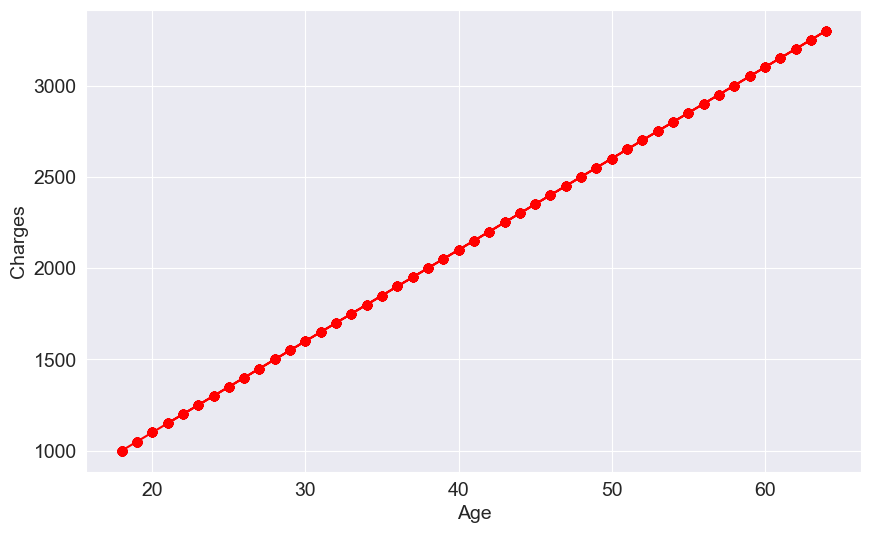

In [34]:
plt.plot(ages , estimate_values , 'r-o')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.show()

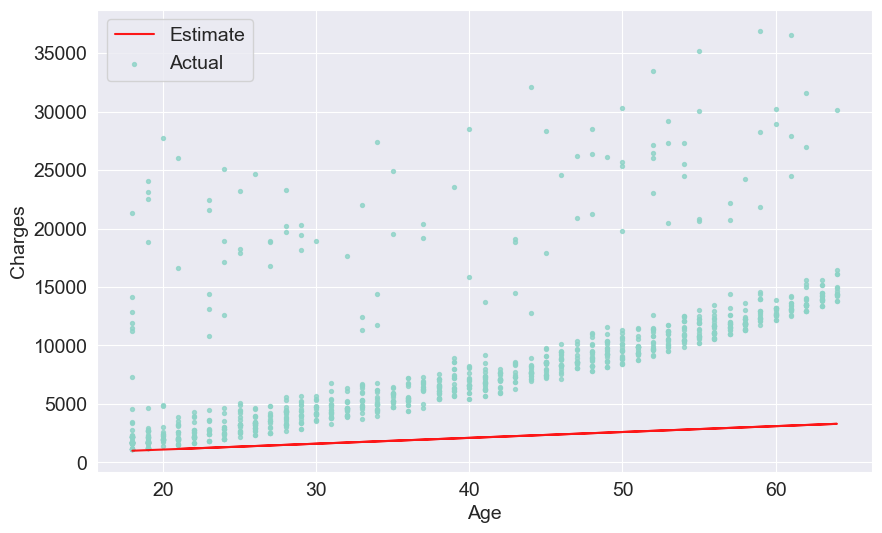

In [35]:
target = non_smoker_df.charges

plt.plot(ages, estimate_values, 'r', alpha=0.9)
plt.scatter(ages, target, s=8,alpha=0.8)
plt.xlabel('Age')
plt.ylabel('Charges')
plt.legend(['Estimate', 'Actual'])

In [36]:
def try_parameter(w,b):
    ages = non_smoker_df.age
    target = non_smoker_df.charges

    estimated_charges = estimate_charges(ages , w , b)

    plt.plot(ages , estimated_charges , 'r-o')
    plt.scatter(ages , target , s=8 , alpha=0.8)
    plt.xlabel('Ages')
    plt.ylabel('Charges')
    plt.legend(['Estimated' , 'Actual'])


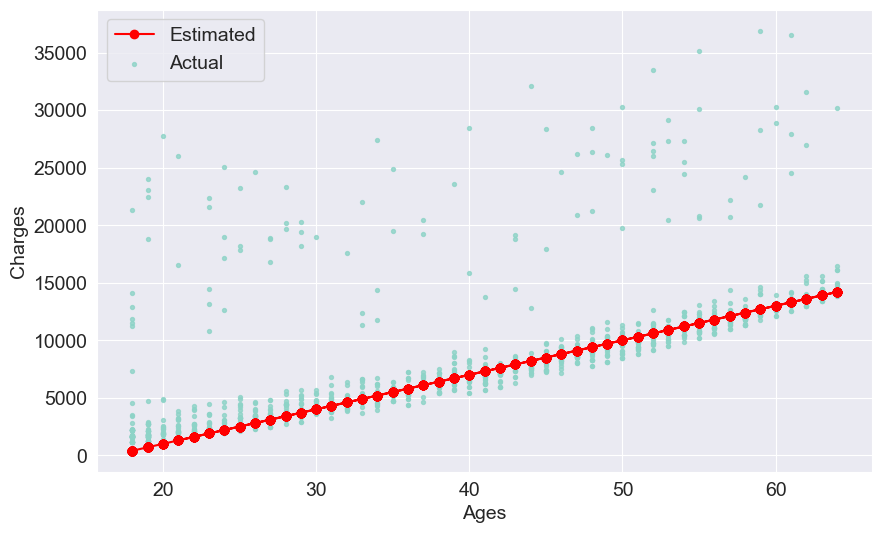

In [37]:
try_parameter(300 , -5000)

# Loss/Cost Function

In [38]:
import numpy as np

In [39]:
def rmse(targets , predictions):
    return np.sqrt(np.mean(np.square(targets - predictions)))

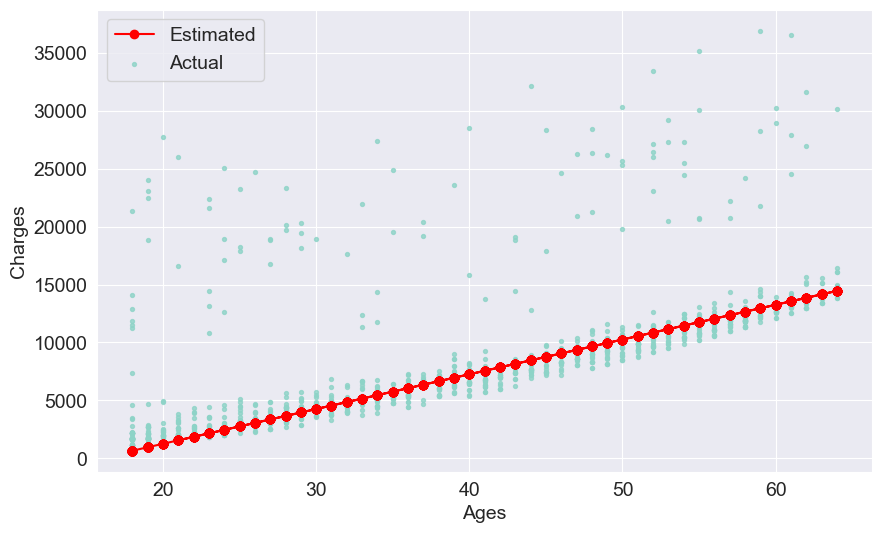

In [40]:
w = 300
b =-4750

try_parameter(w,b)

In [41]:
targets = non_smoker_df['charges']
predicted = estimate_charges(non_smoker_df['age'] , w , b)

In [42]:
print(rmse(targets,predicted))

4881.061119292143


In [43]:
def try_parameters(w, b):
    ages = non_smoker_df.age
    target = non_smoker_df.charges
    predictions = estimate_charges(ages, w, b)

    plt.plot(ages, predictions, 'r', alpha=0.9);
    plt.scatter(ages, target, s=8,alpha=0.8);
    plt.xlabel('Age');
    plt.ylabel('Charges')
    plt.legend(['Prediction', 'Actual']);

    loss = rmse(target, predictions)
    print("RMSE Loss: ", loss)

RMSE Loss:  4816.941379466545


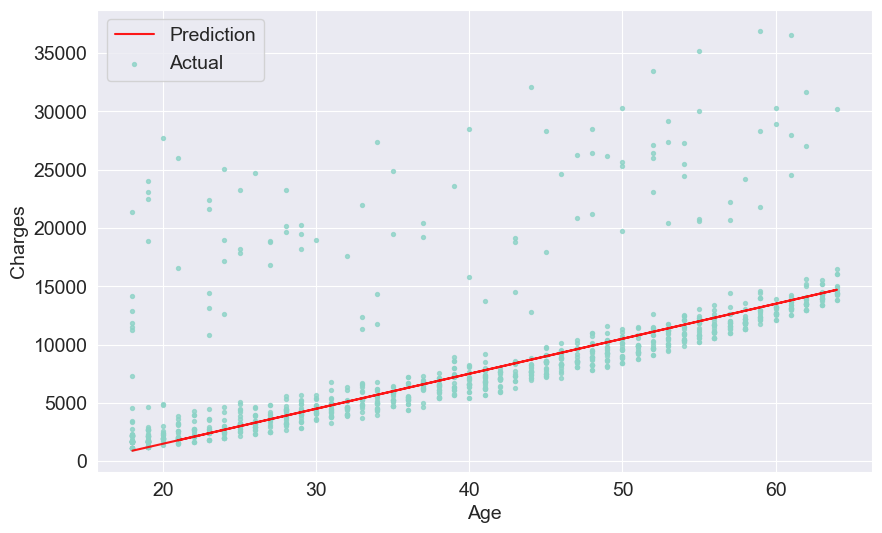

In [44]:
    try_parameters(300 , -4500)

In [45]:
from sklearn.linear_model import LinearRegression

In [46]:
model = LinearRegression()

In [47]:
help(model.fit)

Help on method fit in module sklearn.linear_model._base:

fit(X, y, sample_weight=None) method of sklearn.linear_model._base.LinearRegression instance
    Fit linear model.

    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features)
        Training data.

    y : array-like of shape (n_samples,) or (n_samples, n_targets)
        Target values. Will be cast to X's dtype if necessary.

    sample_weight : array-like of shape (n_samples,), default=None
        Individual weights for each sample.

        .. versionadded:: 0.17
           parameter *sample_weight* support to LinearRegression.

    Returns
    -------
    self : object
        Fitted Estimator.



In [48]:
inputs = non_smoker_df[['age']]
targets = non_smoker_df.charges
print(f"input.shape: {inputs.shape}")
print(f"targets.shape: {targets.shape}")

input.shape: (1064, 1)
targets.shape: (1064,)


In [49]:
model.fit(inputs,targets)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [50]:
model.predict(np.array([[23],[37],[61]]))

C:\Users\RISHABH\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([ 4055.30443855,  7796.78921819, 14210.76312614])

In [51]:
predictions = model.predict(inputs)
print(predictions)

[2719.0598744  5391.54900271 6727.79356686 ... 2719.0598744  2719.0598744
 3520.80661289]


In [53]:
print(rmse(targets, predictions))

4662.505766636395


In [54]:
model.coef_

array([267.24891283])

In [55]:
model.intercept_

np.float64(-2091.4205565650864)

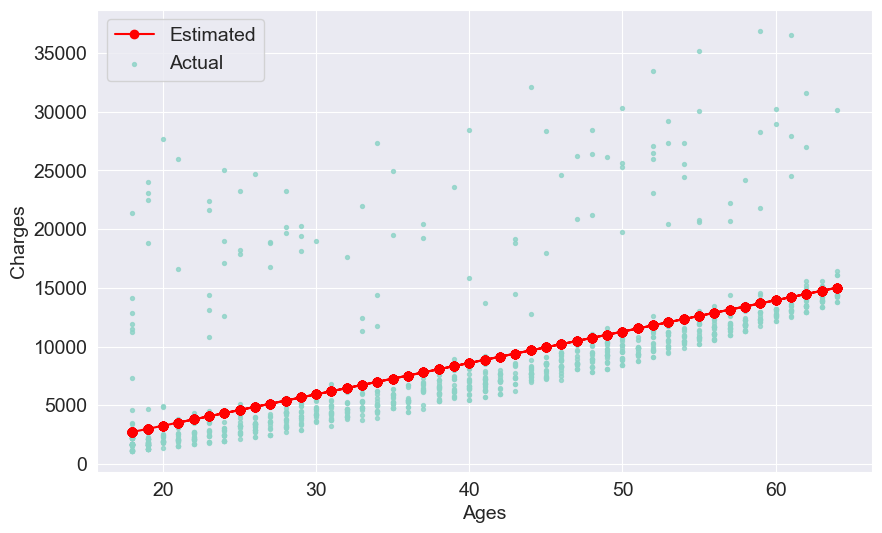

In [56]:
try_parameter(model.coef_ ,model.intercept_ )

In [57]:
from sklearn.linear_model import SGDRegressor

In [58]:
model2 = SGDRegressor()

In [59]:
model2.fit(inputs,targets)

,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide `.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [61]:
predictions2 = model2.predict(inputs)
print(predictions2)

[4369.57793081 6589.79128901 7699.8979681  ... 4369.57793081 4369.57793081
 5035.64193827]


In [62]:
print(rmse(predictions2,targets))

4755.124478492187


In [65]:
model2.coef_

array([222.02133582])

In [66]:
model2.intercept_

array([373.19388606])

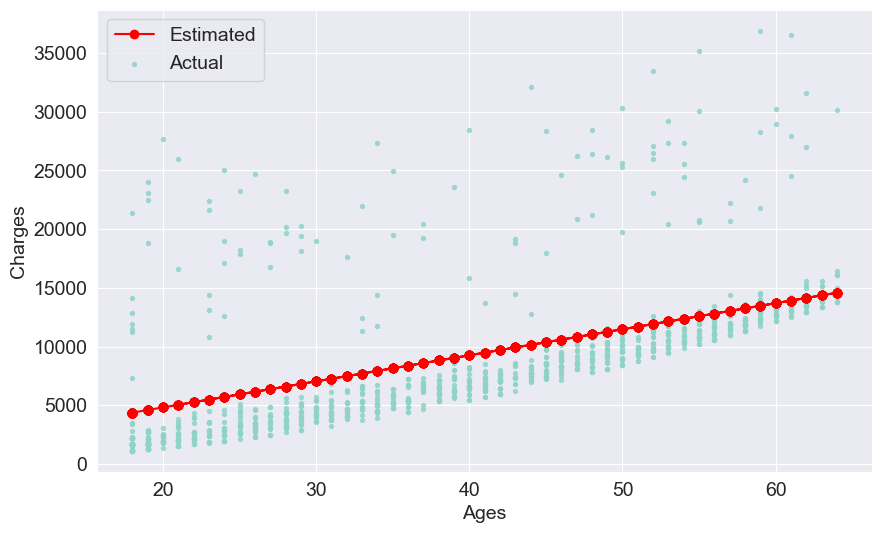

In [67]:
try_parameter(model2.coef_,model2.intercept_ )

In [68]:
inputs = non_smoker_df[['age' , 'bmi']]
targets = non_smoker_df['charges']

model = LinearRegression().fit(inputs , targets)

predictions = model.predict(inputs)

loss = rmse(predictions , targets)

print(f"Loss: {loss}")

Loss: 4662.3128354612945


In [69]:
non_smoker_df.charges.corr(non_smoker_df.bmi)

np.float64(0.08403654312833271)

In [74]:
fig = px.scatter(non_smoker_df , x = 'bmi' , y = 'charges' , title='BMI vs Charges')
fig.update_traces(marker_size = 5)
fig.show()

In [75]:
fig = px.scatter_3d(non_smoker_df , x='age' , y = 'bmi' , z = 'charges')
fig.update_traces(marker_size=3, marker_opacity=0.5)
fig.show()

EXERCISE: Train a linear regression model to estimate charges using BMI alone. Do you expect it to be better or worse than the previously trained models?


In [76]:
inputs = non_smoker_df[['bmi']]
targets = non_smoker_df['charges']

model = LinearRegression().fit(inputs, targets)

predictions = model.predict(inputs)

loss = rmse(predictions, targets)

print(f"Loss: {loss}")

Loss: 5969.772531913293


In [80]:
non_smoker_df.charges.corr(non_smoker_df.children)

np.float64(0.13892870453542205)

In [78]:
fig = px.strip(non_smoker_df, x='children', y='charges', title= "Children vs. Charges")
fig.update_traces(marker_size=4, marker_opacity=0.7)
fig.show()

In [83]:
inputs = non_smoker_df[['age' , 'bmi' , 'children']]
targets = non_smoker_df['charges']

model = LinearRegression().fit(inputs,targets)

predictions = model.predict(inputs)

loss = rmse(predictions , targets)
print(f'Loss: {loss}')

Loss: 4608.470405038246


EXERCISE: Repeat the steps is this section to train a linear regression model to estimate medical charges for smokers. Visualize the targets and predictions, and compute the loss.

In [86]:
smoker_df = medical_df[medical_df.smoker == 'yes']
smoker_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
11,62,female,26.290,0,yes,southeast,27808.72510
14,27,male,42.130,0,yes,southeast,39611.75770
19,30,male,35.300,0,yes,southwest,36837.46700
23,34,female,31.920,1,yes,northeast,37701.87680
...,...,...,...,...,...,...,...
1313,19,female,34.700,2,yes,southwest,36397.57600
1314,30,female,23.655,3,yes,northwest,18765.87545
1321,62,male,26.695,0,yes,northeast,28101.33305
1323,42,female,40.370,2,yes,southeast,43896.37630


In [94]:
inputs = smoker_df[['age' , 'bmi','children']]
targets = smoker_df['charges']

model = LinearRegression().fit(inputs,targets)

predictions = model.predict(inputs)

loss = rmse(predictions , targets)

print(f'Loss: {loss}')

Loss: 5718.202480524154


build model for full data

In [95]:
inputs = medical_df[['age' , 'bmi','children']]
targets = medical_df['charges']

model = LinearRegression().fit(inputs,targets)

predictions = model.predict(inputs)

loss = rmse(predictions , targets)

print(f'Loss: {loss}')

Loss: 11355.317901125973
